# Eksperimen Operasi Dasar pada Sinyal dan Citra

**Mata Kuliah:** Pengolahan Sinyal Digital

**Nama:** Dinda Aliya Nabilah

**NIM:** 452024618082


> Add blockquote



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab.patches import cv2_imshow

## Pembuatan Sinyal


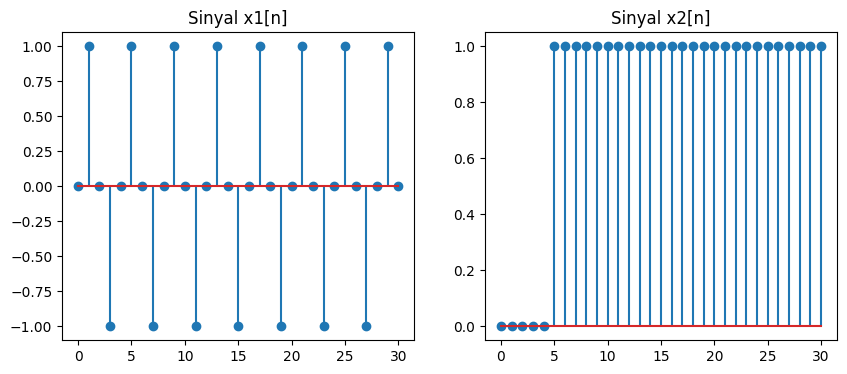

In [2]:
n = np.arange(0,31)

x1 = np.sin(0.5*np.pi*n)
x2 = np.where(n < 5, 0, 1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.stem(n, x1)
plt.title("Sinyal x1[n]")

plt.subplot(1,2,2)
plt.stem(n, x2)
plt.title("Sinyal x2[n]")

plt.show()

## Penjumlahan Sinyal

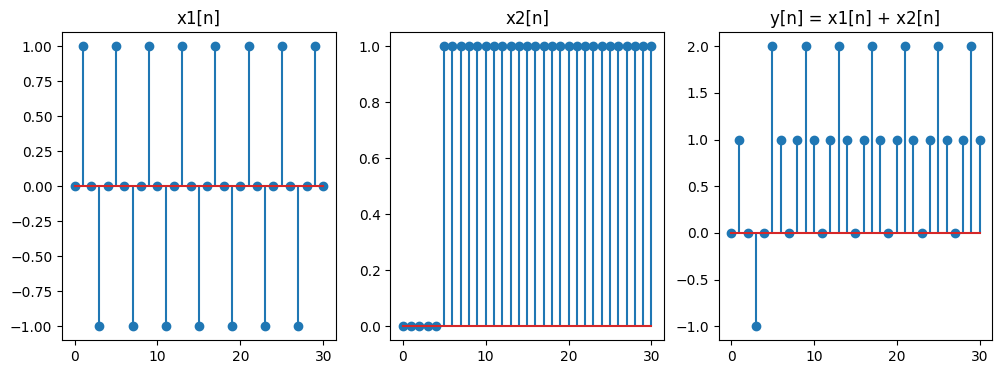

In [3]:
y = x1 + x2

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.stem(n,x1)
plt.title("x1[n]")

plt.subplot(1,3,2)
plt.stem(n,x2)
plt.title("x2[n]")

plt.subplot(1,3,3)
plt.stem(n,y)
plt.title("y[n] = x1[n] + x2[n]")

plt.show()

## Penggeseran Sinyal

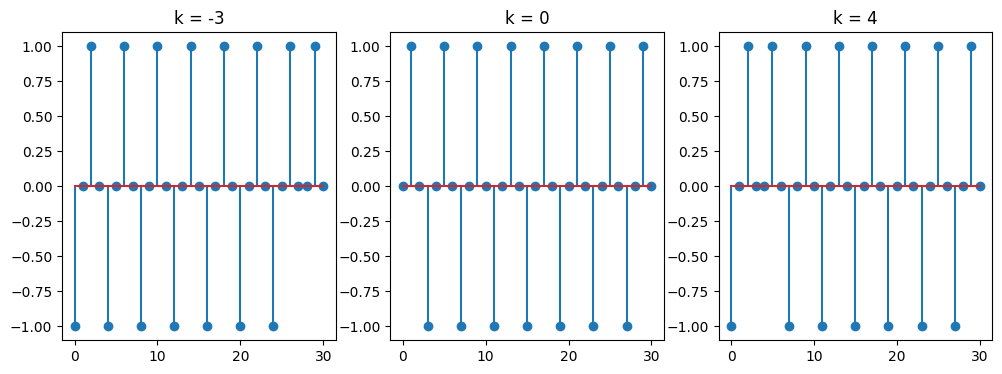

In [4]:
k_values = [-3,0,4]

plt.figure(figsize=(12,4))

for i,k in enumerate(k_values):
    y_shift = np.roll(x1,k)

    plt.subplot(1,3,i+1)
    plt.stem(n,y_shift)
    plt.title(f"k = {k}")

plt.show()

## Amplifikasi

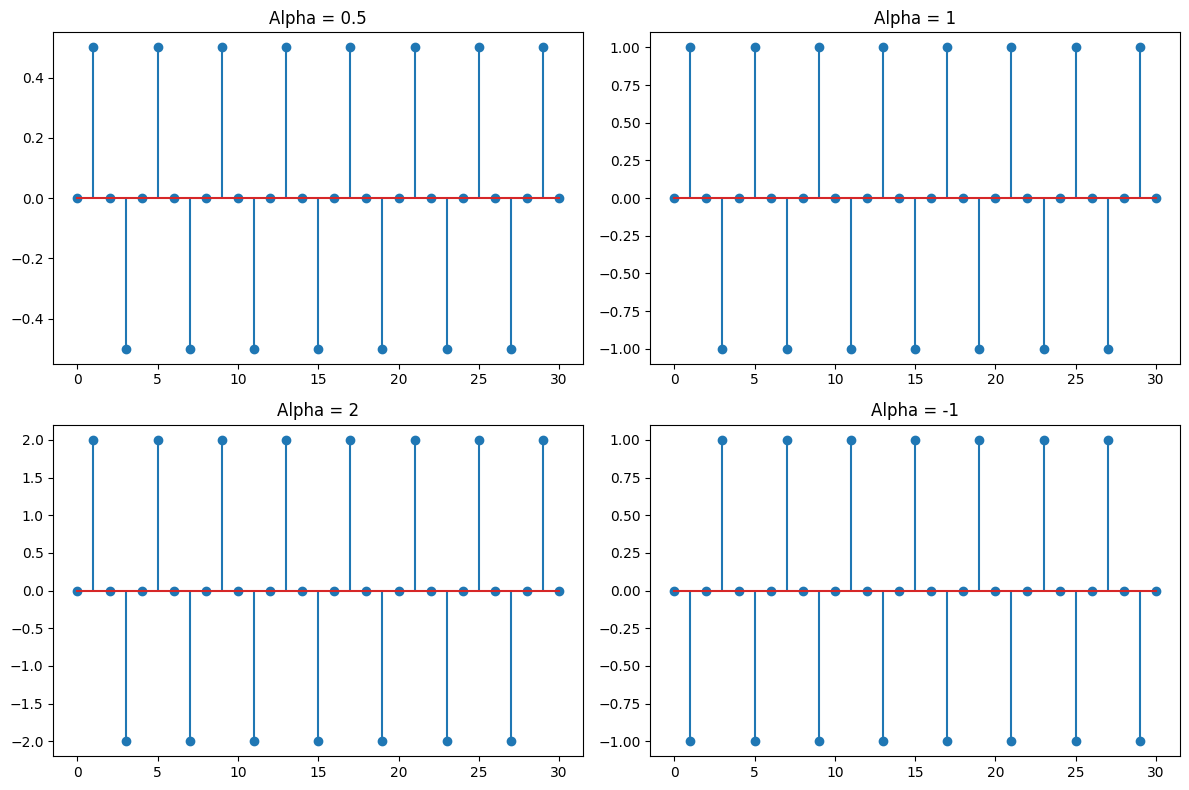

In [5]:
alpha_values = [0.5,1,2,-1]

plt.figure(figsize=(12,8))

for i,a in enumerate(alpha_values):
    y_amp = a*x1

    plt.subplot(2,2,i+1)
    plt.stem(n,y_amp)
    plt.title(f"Alpha = {a}")

plt.tight_layout()
plt.show()

## Citra

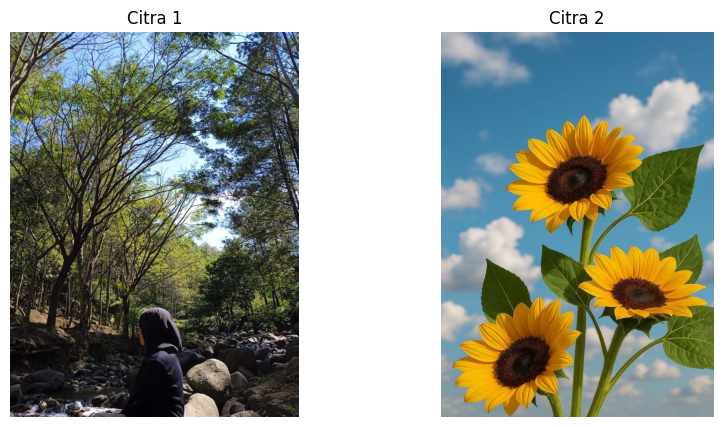

In [12]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img1 = cv2.imread('citra.jpg')
img2 = cv2.imread('citra2.jpg')

img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img1_rgb)
plt.title("Citra 1")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img2_rgb)
plt.title("Citra 2")
plt.axis('off')

plt.show()

## Penampilan Informasi Citra

In [13]:
print("=== CITRA 1 ===")
print("Ukuran :", img1.shape)
print("Tipe Data :", img1.dtype)
print("Pixel Minimum :", img1.min())
print("Pixel Maksimum :", img1.max())

print("\n=== CITRA 2 ===")
print("Ukuran :", img2.shape)
print("Tipe Data :", img2.dtype)
print("Pixel Minimum :", img2.min())
print("Pixel Maksimum :", img2.max())

=== CITRA 1 ===
Ukuran : (1040, 780, 3)
Tipe Data : uint8
Pixel Minimum : 0
Pixel Maksimum : 255

=== CITRA 2 ===
Ukuran : (1040, 736, 3)
Tipe Data : uint8
Pixel Minimum : 0
Pixel Maksimum : 255


## Penjumlahan Citra

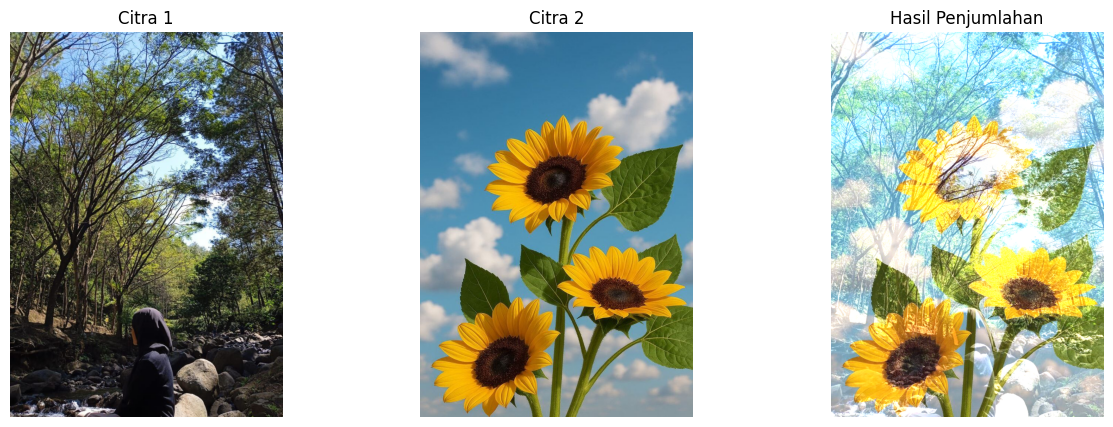

In [16]:
height = min(img1.shape[0], img2.shape[0])
width = min(img1.shape[1], img2.shape[1])

img1_resize = cv2.resize(img1, (width, height))
img2_resize = cv2.resize(img2, (width, height))

hasil_tambah = cv2.add(img1_resize, img2_resize)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img1_resize, cv2.COLOR_BGR2RGB))
plt.title("Citra 1")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(img2_resize, cv2.COLOR_BGR2RGB))
plt.title("Citra 2")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(hasil_tambah, cv2.COLOR_BGR2RGB))
plt.title("Hasil Penjumlahan")
plt.axis('off')

plt.show()

## Penggeseran Citra

In [20]:
rows, cols = img1_resize.shape[:2]

M1 = np.float32([
    [1,0,30],
    [0,1,0]
])

shift1 = cv2.warpAffine(img1_resize, M1, (cols, rows))

M2 = np.float32([
    [1,0,0],
    [0,1,30]
])

shift2 = cv2.warpAffine(img1_resize, M2, (cols, rows))

M3 = np.float32([
    [1,0,30],
    [0,1,30]
])

shift3 = cv2.warpAffine(img1_resize, M3, (cols, rows))




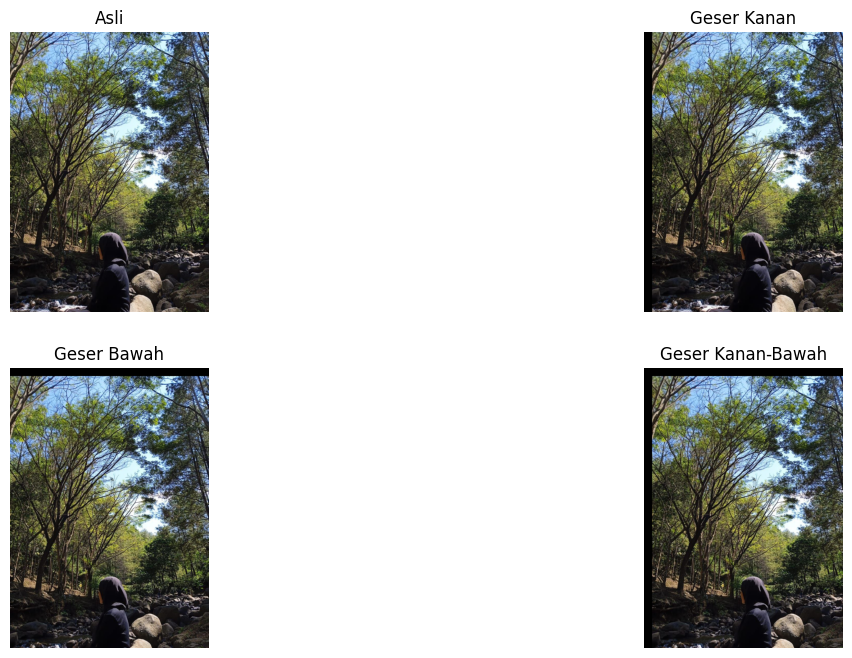

In [21]:
plt.figure(figsize=(15,8))

plt.subplot(2,2,1)
plt.imshow(cv2.cvtColor(img1_resize, cv2.COLOR_BGR2RGB))
plt.title("Asli")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(cv2.cvtColor(shift1, cv2.COLOR_BGR2RGB))
plt.title("Geser Kanan")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(cv2.cvtColor(shift2, cv2.COLOR_BGR2RGB))
plt.title("Geser Bawah")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(cv2.cvtColor(shift3, cv2.COLOR_BGR2RGB))
plt.title("Geser Kanan-Bawah")
plt.axis('off')

plt.show()

## Amplifikasi Citra

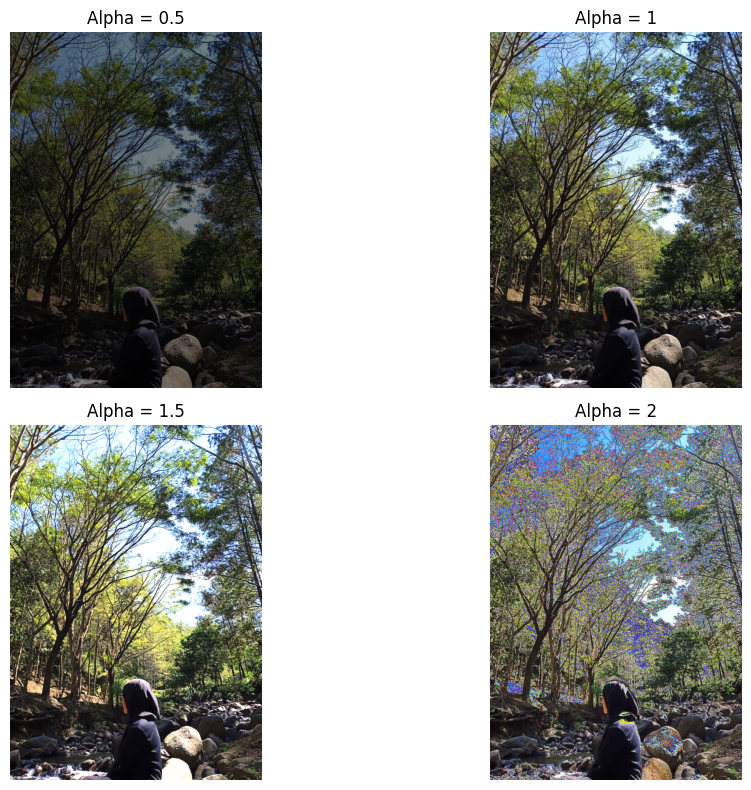

In [22]:
alpha_values = [0.5, 1, 1.5, 2]

plt.figure(figsize=(12,8))

for i, alpha in enumerate(alpha_values):

    hasil = np.clip(
        img1_resize * alpha,
        0,
        255
    ).astype(np.uint8)

    plt.subplot(2,2,i+1)
    plt.imshow(cv2.cvtColor(hasil, cv2.COLOR_BGR2RGB))
    plt.title(f"Alpha = {alpha}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Histogram Sebelum dan Sesudah Amplifikasi

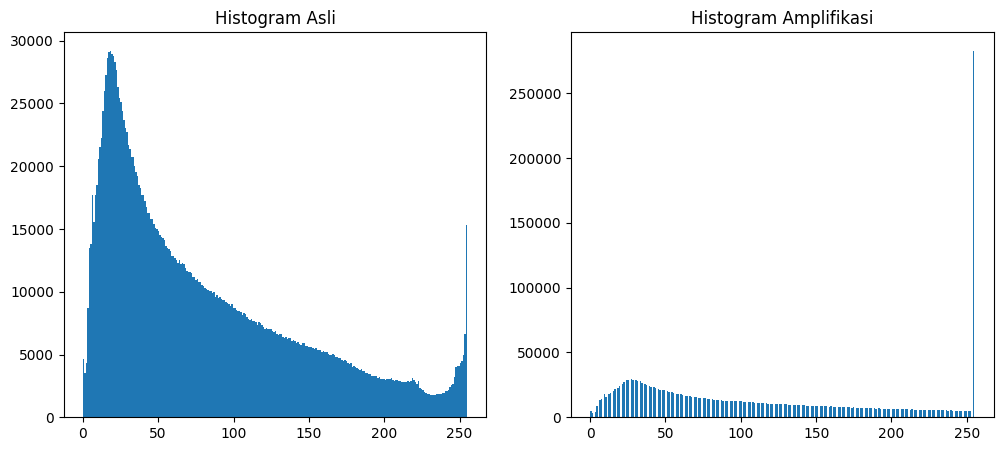

In [23]:
bright = np.clip(
    img1_resize * 1.5,
    0,
    255
).astype(np.uint8)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(img1_resize.ravel(), bins=256)
plt.title("Histogram Asli")

plt.subplot(1,2,2)
plt.hist(bright.ravel(), bins=256)
plt.title("Histogram Amplifikasi")

plt.show()

## Homogenitas

In [24]:
alpha = 2

left = 2*(alpha*x1)
right = alpha*(2*x1)

print(np.allclose(left,right))


True


## Additivitas

In [25]:
left = 2*(x1+x2)
right = (2*x1)+(2*x2)

print(np.allclose(left,right))

True


## Sistem Non-Linier

In [26]:
left = (x1+x2)**2
right = x1**2 + x2**2

print(np.allclose(left,right))

False
